# 06 — Model Evaluation

## Looking past the headline score

Notebook 05 picked a winner (Random Forest) using aggregate metrics
(MAE/RMSE/MAPE). Aggregate metrics can hide important problems - a model
might have a great average error but consistently fail on specific days
(e.g. always underpredicting big sale days). This notebook digs into the
**residuals** (actual - predicted) to answer:

1. Are errors random, or is there a pattern (bias) the model is missing?
2. Does the model struggle more on certain days of week / months?
3. Is error size related to revenue size (heteroscedasticity)?
4. How does the winning model perform vs. every other candidate, side by side?

This is what separates "we picked the model with the best score" from
"we understand where and why this model can be trusted."

In [1]:
import sys
sys.path.append("../src")

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ecommerce_sales_analysis.model import time_based_split, compute_metrics

sns.set_theme(style="whitegrid")

features = pd.read_csv('../data/processed/features.csv', index_col=0, parse_dates=True)
X_train, X_test, y_train, y_test = time_based_split(features, test_size=0.2)

with open('../data/processed/trained_models.pkl', 'rb') as f:
    fitted_models = pickle.load(f)

results = pd.read_csv('../data/processed/model_results.csv', index_col=0)
best_model_name = results.index[0]
if best_model_name.startswith('Baseline'):
    best_model_name = results.index[1]  # fall back to best real model
best_model = fitted_models[best_model_name]

print(f"Evaluating best model: {best_model_name}")
results

Evaluating best model: RandomForest


,MAE,RMSE,MAPE
RandomForest,9700.318320,17663.936800,32.447958
GradientBoosting,9923.444624,18172.788715,33.054296
LinearRegression,11587.602248,18537.046543,32.687784
Baseline (naive lag-1),20095.526056,26594.034198,55.595973


In [2]:
predictions = pd.Series(best_model.predict(X_test), index=X_test.index, name='Predicted')
residuals = y_test - predictions
residuals.name = 'Residual'

print(compute_metrics(y_test, predictions.values))

{'MAE': 9700.318319960628, 'RMSE': np.float64(17663.936799510528), 'MAPE': 32.44795802631856}


## 1. Residuals over time — is the error random, or does it drift?

A healthy model's residuals should bounce around zero with no obvious
pattern. A residual that trends consistently positive or negative over time
means the model has a systematic bias (e.g. it's not tracking a trend it
should be picking up on).

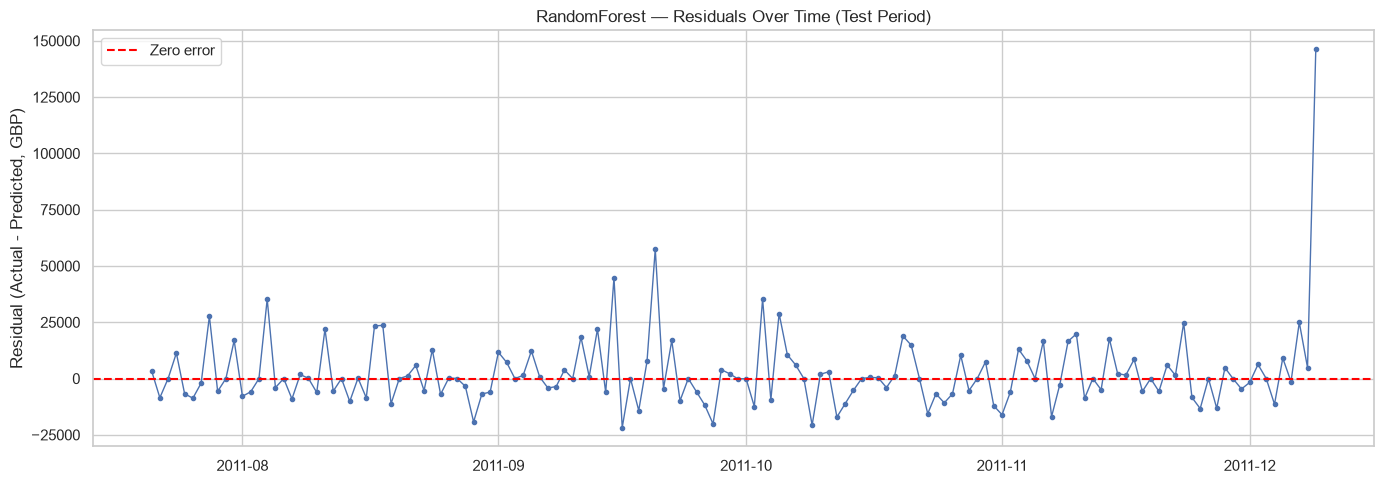

Mean residual: 2522.68 (close to 0 = no systematic bias)


In [3]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(residuals.index, residuals.values, marker='o', markersize=3, linewidth=1)
ax.axhline(0, color='red', linestyle='--', label='Zero error')
ax.set_title(f'{best_model_name} — Residuals Over Time (Test Period)')
ax.set_ylabel('Residual (Actual - Predicted, GBP)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():.2f} (close to 0 = no systematic bias)")

## 2. Residual distribution — are errors roughly symmetric?

A roughly bell-shaped, zero-centered distribution suggests errors are
"normal" noise. A skewed distribution (e.g. a long tail of large
under-predictions) suggests the model consistently misses certain kinds
of days - worth investigating which ones.

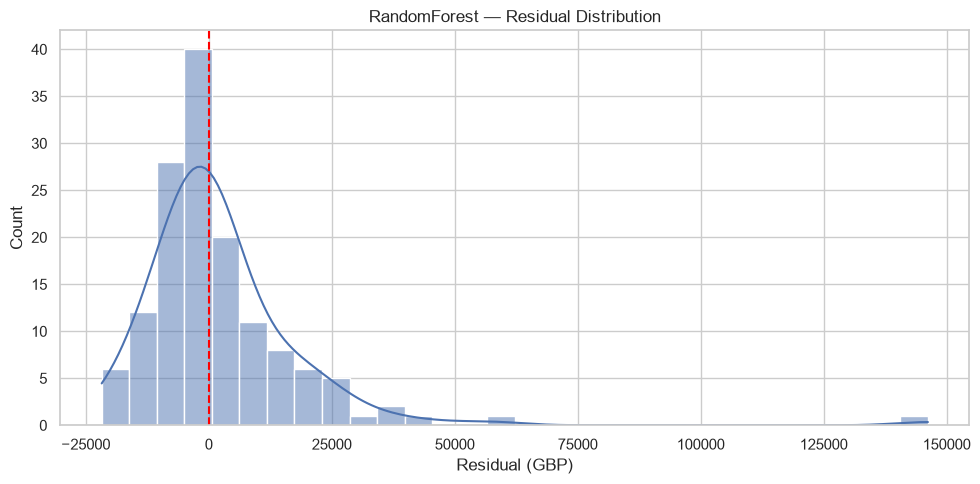

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(residuals, bins=30, kde=True, ax=ax)
ax.axvline(0, color='red', linestyle='--')
ax.set_title(f'{best_model_name} — Residual Distribution')
ax.set_xlabel('Residual (GBP)')
plt.tight_layout()
plt.show()

## 3. Error by day of week — does the model struggle on specific days?

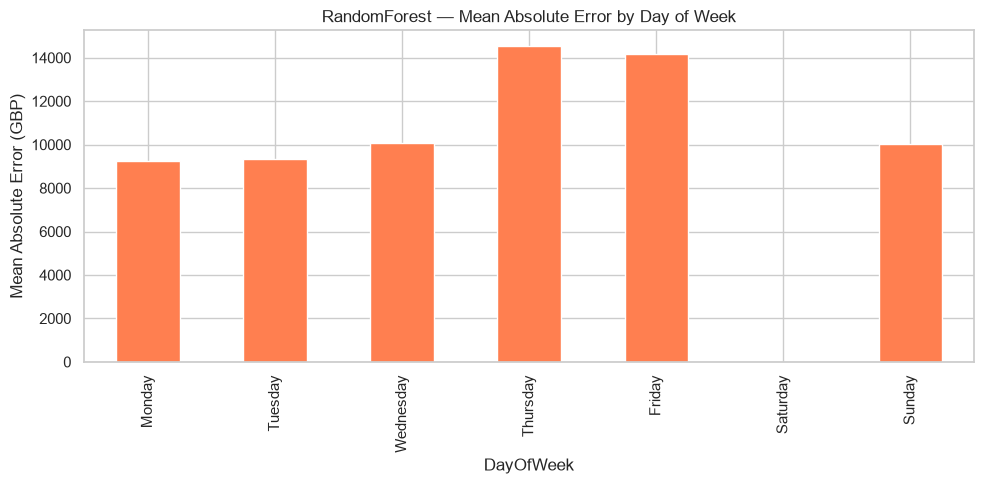

In [5]:
eval_df = pd.DataFrame({'Actual': y_test, 'Predicted': predictions, 'Residual': residuals})
eval_df['AbsError'] = eval_df['Residual'].abs()
eval_df['DayOfWeek'] = eval_df.index.day_name()

dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_error = eval_df.groupby('DayOfWeek')['AbsError'].mean().reindex(dow_order)

dow_error.plot(kind='bar', figsize=(10, 5), color='coral', title=f'{best_model_name} — Mean Absolute Error by Day of Week')
plt.ylabel('Mean Absolute Error (GBP)')
plt.tight_layout()
plt.show()

## 4. Predicted vs Actual scatter — perfect predictions fall on the diagonal

Points on the red diagonal line are perfect predictions. Points far above
the line are under-predictions (actual > predicted); points far below are
over-predictions. This also reveals whether errors grow with the size of
the revenue being predicted (heteroscedasticity).

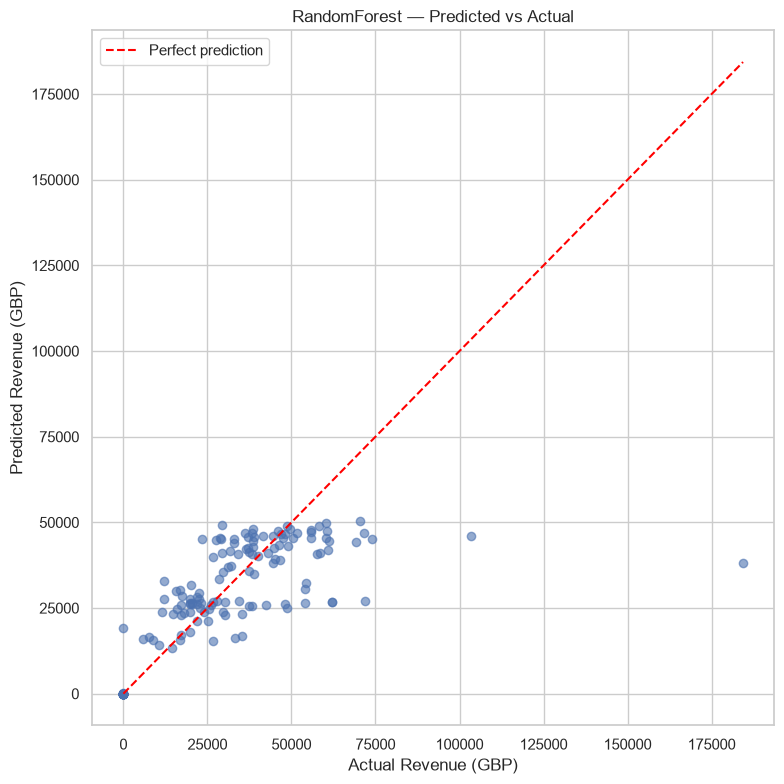

In [6]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, predictions, alpha=0.6)
max_val = max(y_test.max(), predictions.max())
ax.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Perfect prediction')
ax.set_xlabel('Actual Revenue (GBP)')
ax.set_ylabel('Predicted Revenue (GBP)')
ax.set_title(f'{best_model_name} — Predicted vs Actual')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Worst predictions — what do the biggest misses have in common?

In [7]:
worst = eval_df.sort_values('AbsError', ascending=False).head(10)
worst[['Actual', 'Predicted', 'Residual', 'DayOfWeek']]

,Actual,Predicted,Residual,DayOfWeek
Date,,,,
2011-12-09,184347.66,38162.283906,146185.376094,Friday
2011-09-20,103377.68,45891.187658,57486.492342,Tuesday
2011-09-15,71926.69,27138.365744,44788.324256,Thursday
2011-10-03,62143.07,26815.559671,35327.510329,Monday
2011-08-04,62074.19,26814.242929,35259.947071,Thursday
2011-10-05,73975.57,45124.173627,28851.396373,Wednesday
2011-07-28,54171.95,26511.808329,27660.141671,Thursday
2011-12-07,69230.60,44277.287694,24953.312306,Wednesday
2011-11-23,71722.75,46980.519065,24742.230935,Wednesday


## All models compared side-by-side

Recap from Notebook 05 - keeping this here too since evaluation should
always show the full comparison, not just the winner in isolation.

In [8]:
results.style.highlight_min(subset=['MAE', 'RMSE', 'MAPE'], color='lightgreen')

,MAE,RMSE,MAPE
RandomForest,9700.318320,17663.936800,32.447958
GradientBoosting,9923.444624,18172.788715,33.054296
LinearRegression,11587.602248,18537.046543,32.687784
Baseline (naive lag-1),20095.526056,26594.034198,55.595973


## Summary

_Fill this in after running the cells above:_
- Is the mean residual close to 0 (no systematic bias), or does the model
  consistently over/under-predict?
- Does error increase on certain days of week (e.g. does the model struggle
  more when revenue is unusually high or low)?
- Looking at the worst 10 predictions - do they share something in common
  (e.g. all near a holiday, all unusually large spikes)?
- Given all of this, do we trust this model enough to use it for actual
  predictions? What are its known limitations?

Next: **Notebook 07 - Prediction & Final Report**, where we use the chosen
model to forecast future sales and summarize the whole project's findings.